# [Python Reference Link](http://www.data8.org/sp20/python-reference.html)
*Run the cell below so that we can set our modules up*# Importing our modules

In [1]:
import numpy as np
from datascience import *
import math as m

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

# Linear Regression

## Standard Units

In [2]:
birds = Table.read_table('snowy_plover.csv')
birds

Egg Length,Egg Breadth,Egg Weight,Bird Weight
28.8,21.84,7.4,5.2
29.04,22.45,7.7,5.4
29.36,22.48,7.9,5.6
30.1,21.71,7.5,5.3
30.17,22.75,8.3,5.9
30.34,22.84,8.5,5.8
30.36,22.5,8.2,5.8
30.46,22.72,8.3,6
30.54,23.31,9,6.1
30.62,22.94,8.5,6.2


Let's take a look at the relationship between Egg Weight and Bird Weight

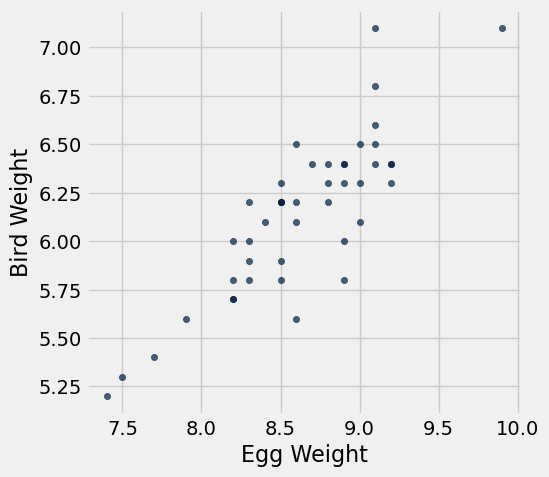

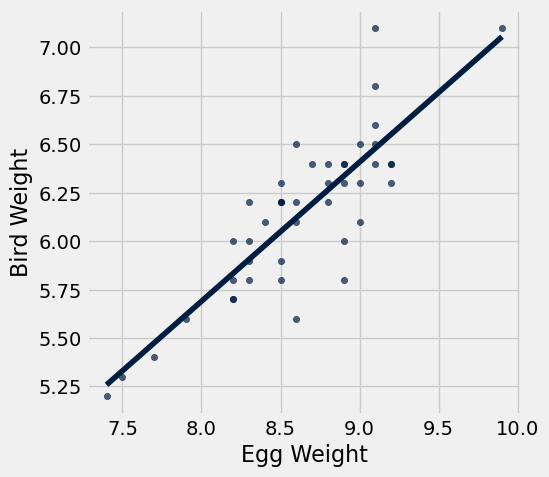

In [6]:
birds.scatter('Egg Weight','Bird Weight')
birds.scatter('Egg Weight','Bird Weight',fit_line=True)

Now let's calculate the standard units for each weight variable:

In [10]:
array_values = birds.column('Egg Weight')
e_weight_standard_units = (array_values - np.average(array_values))/np.std(array_values)
print(e_weight_standard_units)

print(np.mean(birds.column('Egg Weight')),np.std(birds.column('Egg Weight')))
Table().with_columns('original', birds.column('Egg Weight'), 'standard units', e_weight_standard_units)

[-2.57850339 -1.95168489 -1.53380588 -2.36956389 -0.69804788 -0.28016888
 -0.90698738 -0.69804788  0.76452863 -0.28016888 -0.07122938 -0.90698738
 -0.69804788  0.13771013 -0.28016888 -0.48910838 -0.28016888  0.55558913
  0.97346813  0.55558913 -0.07122938 -0.28016888  0.34664963 -0.69804788
 -0.90698738 -0.90698738  0.55558913 -0.28016888  0.34664963 -0.07122938
  0.97346813  0.76452863  0.55558913  1.18240763  0.97346813 -0.07122938
  0.34664963  0.97346813  1.18240763  1.18240763  0.55558913  0.97346813
  2.64498414  0.76452863]
8.63409090909 0.478607441067


original,standard units
7.4,-2.5785
7.7,-1.95168
7.9,-1.53381
7.5,-2.36956
8.3,-0.698048
8.5,-0.280169
8.2,-0.906987
8.3,-0.698048
9,0.764529
8.5,-0.280169


In [11]:
array_values = birds.column('Bird Weight')
b_weight_standard_units = (array_values - np.average(array_values))/np.std(array_values)
b_weight_standard_units

array([-2.32929889, -1.83656258, -1.34382628, -2.08293074, -0.60472183,
       -0.85108998, -0.85108998, -0.35835368, -0.11198552,  0.13438263,
        0.87348708, -1.09745813,  0.13438263,  0.62711893,  0.13438263,
       -0.11198552,  0.38075078,  0.38075078,  0.87348708, -0.35835368,
       -1.34382628,  0.13438263,  0.38075078, -0.85108998, -1.09745813,
       -0.35835368,  0.62711893, -0.60472183,  0.62711893,  0.13438263,
        2.35169599,  0.87348708, -0.85108998,  0.62711893,  0.62711893,
       -0.11198552,  0.13438263,  1.61259154,  0.38075078,  0.62711893,
        0.62711893,  1.11985523,  2.35169599,  0.38075078])

In [13]:
# to simplify, let's turn this process into a function
def standard_units_convert(input_data):
    standard_units = (input_data - np.average(input_data))/np.std(input_data)
    return standard_units

In [14]:
standard_units_convert(birds.column('Bird Weight')) == b_weight_standard_units

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True], dtype=bool)

## Correlation Coefficient `r`

In [17]:
correlation_r = np.mean(standard_units_convert(birds.column('Bird Weight')) * standard_units_convert(birds.column('Egg Weight')))
correlation_r

0.84722752951013713

In [18]:
def calculate_r(x_value_array, y_value_array):
    x_standard_units = standard_units_convert(x_value_array)
    y_standard_units = standard_units_convert(y_value_array)
    return np.mean(x_standard_units * y_standard_units)

In [19]:
calculate_r(birds.column('Egg Weight'),birds.column('Bird Weight'))

0.84722752951013713

In [20]:
calculate_r(birds.column('Egg Length'),birds.column('Bird Weight'))

0.67614190426662413

## Linear Regression (Slope and Intercept)

In [23]:
# finding the standard deviations for our x-value & y-value arrays
x_val_sd = np.std(birds.column('Egg Weight'))
y_val_sd = np.std(birds.column('Bird Weight'))
print(correlation_r, x_val_sd, y_val_sd)

0.84722752951 0.478607441067 0.405896619986


In [24]:
slope_of_regression = correlation_r * (y_val_sd/x_val_sd)
slope_of_regression

0.7185153448936793

In [26]:
#finding the means for our x-value & y-value arrays
x_val_mean = np.mean(birds.column('Egg Weight'))
y_val_mean = np.mean(birds.column('Bird Weight'))
print(slope_of_regression, x_val_mean, y_val_mean)

0.718515344894 8.63409090909 6.14545454545


In [27]:
intercept = y_val_mean - slope_of_regression*x_val_mean
intercept

-0.058272261934288139

In [28]:
x_val_array = birds.column('Egg Weight')
y_estimates_array = slope_of_regression * x_val_array + intercept
birds = birds.with_columns('Estimates',y_estimates_array)
birds

Egg Length,Egg Breadth,Egg Weight,Bird Weight,Estimates
28.8,21.84,7.4,5.2,5.25874
29.04,22.45,7.7,5.4,5.4743
29.36,22.48,7.9,5.6,5.618
30.1,21.71,7.5,5.3,5.33059
30.17,22.75,8.3,5.9,5.90541
30.34,22.84,8.5,5.8,6.04911
30.36,22.5,8.2,5.8,5.83355
30.46,22.72,8.3,6,5.90541
30.54,23.31,9,6.1,6.40837
30.62,22.94,8.5,6.2,6.04911


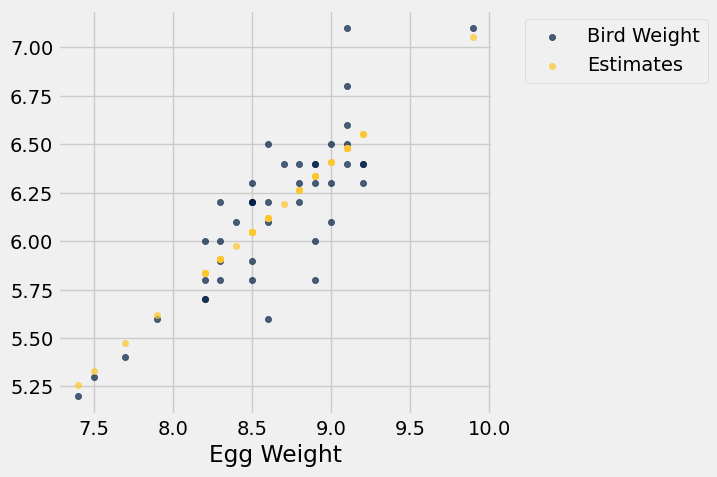

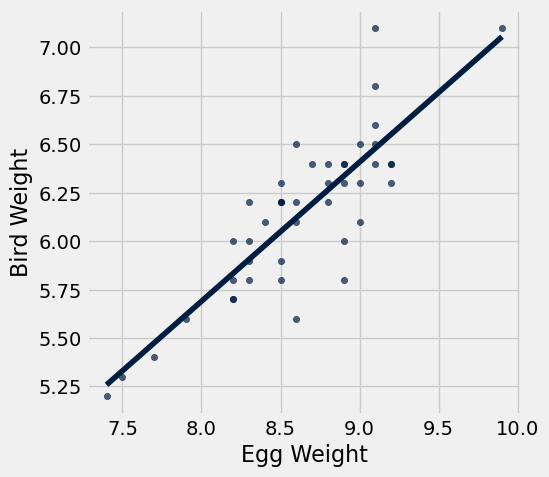

In [30]:
birds.select('Egg Weight','Bird Weight','Estimates').scatter('Egg Weight')
birds.scatter('Egg Weight','Bird Weight',fit_line=True)

## The Residual - Evaluating your Linear Regression Accuracy

In [31]:
residual = birds.column('Bird Weight')- y_estimates_array

In [32]:
birds = birds.with_columns('Residual',residual)
birds

Egg Length,Egg Breadth,Egg Weight,Bird Weight,Estimates,Residual
28.8,21.84,7.4,5.2,5.25874,-0.0587413
29.04,22.45,7.7,5.4,5.4743,-0.0742959
29.36,22.48,7.9,5.6,5.618,-0.017999
30.1,21.71,7.5,5.3,5.33059,-0.0305928
30.17,22.75,8.3,5.9,5.90541,-0.0054051
30.34,22.84,8.5,5.8,6.04911,-0.249108
30.36,22.5,8.2,5.8,5.83355,-0.0335536
30.46,22.72,8.3,6,5.90541,0.0945949
30.54,23.31,9,6.1,6.40837,-0.308366
30.62,22.94,8.5,6.2,6.04911,0.150892


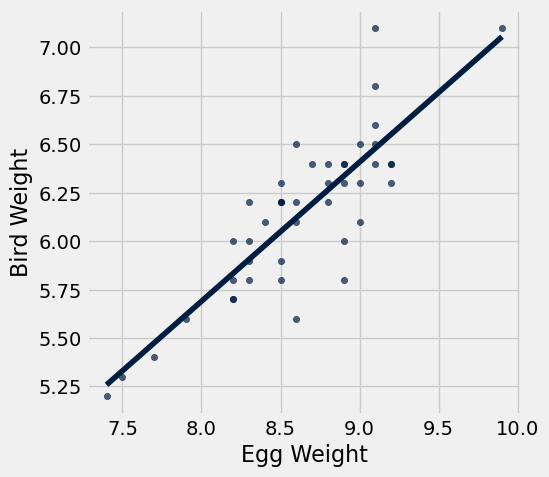

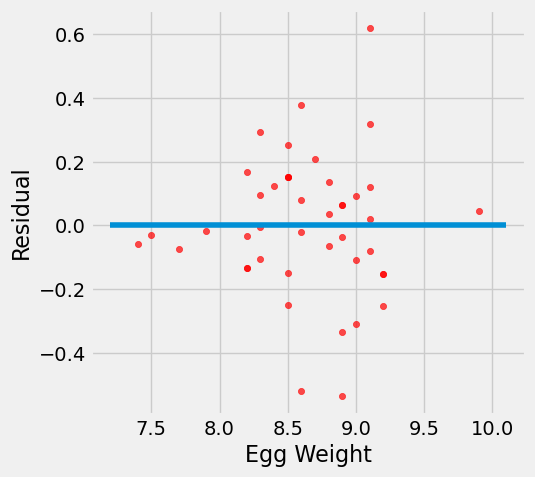

In [33]:
birds.scatter('Egg Weight','Bird Weight',fit_line=True)
birds.scatter('Egg Weight','Residual',color = 'r')
plt.plot(make_array(min(birds.column('Egg Weight'))-.2,max(birds.column('Egg Weight'))+.2), np.zeros(2))